# 1. Imports

In [1]:
import json, os, random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict, Counter

# 2. Config

In [31]:
GRAPHDATA_PATH = r'C:\Users\Anonymous\Downloads\DeepTraLog-main (1)\DeepTraLog-main\GraphData'
SAVE_PATH_A2   = r'A2_reinforce_scratch.pt'
SAVE_PATH_A3   = r'A3_reinforce_pretrain.pt'
 
# Training hyperparameters
A2_EPISODES     = 1000
A2_LR           = 1e-3
A3_PRETRAIN_EP  = 30
A3_PRETRAIN_LR  = 1e-3
A3_PRETRAIN_BS  = 32
A3_FINETUNE_EP  = 2000
A3_FINETUNE_LR  = 1e-4
A3_ENTROPY      = 0.01
SEED            = 42
NOISE        = 0.3

ACTIONS    = ["RESTART", "SCALE_UP", "CIRCUIT_BREAK", "REROUTE", "ROLLBACK"]
ACTION2IDX = {a: i for i, a in enumerate(ACTIONS)}
 
GROUND_TRUTH = {
    "F01": "ROLLBACK",      "F02": "ROLLBACK",
    "F03": "SCALE_UP",      "F04": "RESTART",
    "F05": "SCALE_UP",      "F06": "CIRCUIT_BREAK",
    "F07": "REROUTE",       "F08": "RESTART",
    "F09": "ROLLBACK",      "F10": "ROLLBACK",
    "F11": "ROLLBACK",      "F12": "ROLLBACK",
    "F13": "ROLLBACK",      "F14": "RESTART",
    "F23": "CIRCUIT_BREAK", "F24": "REROUTE",
    "F25": "SCALE_UP",      "unknown": "ROLLBACK",
}
 
MTTR_CORRECT = lambda: round(np.random.normal(4.5, 0.8), 1)
MTTR_WRONG   = lambda: round(np.random.normal(12.0, 2.0), 1)

#  3. Shared Helpers

In [4]:
def get_fault_category(fault_type):
    return fault_type.split('-')[0] if '-' in fault_type else fault_type
 
def build_state(category, score=0.8, noise_level=0.0):
    state = [
        score,
        1.0 if category in ("F04","F08","F14") else 0.0,
        1.0 if category in ("F06","F07","F23") else 0.0,
        1.0 if category in ("F03","F05","F25") else 0.0,
        1.0 if category in ("F07","F24")        else 0.0,
        1.0,
    ]
    if noise_level > 0:
        noise = np.random.normal(0, noise_level, len(state))
        state = np.clip(np.array(state) + noise, 0.0, 1.0).tolist()
    return state
 
def load_all_traces(path):
    traces = []
    for fname in sorted(f for f in os.listdir(path) if f.endswith('.jsons')):
        with open(os.path.join(path, fname), 'r') as f:
            for line in f:
                line = line.strip()
                if not line: continue
                try:
                    g = json.loads(line)
                    if not g['trace_bool']:
                        cat = get_fault_category(g.get('error_trace_type','unknown'))
                        if cat in GROUND_TRUTH:
                            traces.append({
                                'category': cat,
                                'correct':  GROUND_TRUTH[cat],
                                'label':    ACTION2IDX[GROUND_TRUTH[cat]],
                            })
                except: continue
    return traces
 

# 4. Load Data

In [5]:
print(f"Loading GraphData from {GRAPHDATA_PATH}...")
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
 
all_traces = load_all_traces(GRAPHDATA_PATH)
print(f"Total anomalous traces: {len(all_traces)}")
 
dist = Counter(t['category'] for t in all_traces)
print(f"\nFault distribution:")
for cat, count in sorted(dist.items()):
    print(f"  {cat}: {count} traces")
 
random.shuffle(all_traces)
split      = int(len(all_traces) * 0.8)
train_data = all_traces[:split]
test_data  = all_traces[split:]
print(f"\nTrain: {len(train_data)}  Test: {len(test_data)}")

Loading GraphData from C:\Users\Anonymous\Downloads\DeepTraLog-main (1)\DeepTraLog-main\GraphData...
Total anomalous traces: 23334

Fault distribution:
  F01: 2053 traces
  F02: 2151 traces
  F03: 2564 traces
  F04: 2546 traces
  F05: 1665 traces
  F07: 2309 traces
  F08: 1098 traces
  F11: 1747 traces
  F12: 1174 traces
  F13: 1779 traces
  F14: 870 traces
  F23: 1500 traces
  F24: 978 traces
  F25: 900 traces

Train: 18667  Test: 4667


# 5. Evaluation Helper

In [6]:
def evaluate_agent(predict_fn, traces, label, noise_level=0.0):
    """Generic evaluation for any agent."""
    results       = []
    fault_correct = defaultdict(int)
    fault_counts  = defaultdict(int)
    action_counts = defaultdict(int)
    mttrs         = []
 
    for trace in traces:
        cat        = trace['category']
        correct    = trace['correct']
        score      = round(random.uniform(0.5, 1.0), 3)
        state      = build_state(cat, score, noise_level)
        action     = predict_fn(state, cat)
        is_correct = (action == correct)
        mttr       = MTTR_CORRECT() if is_correct else MTTR_WRONG()
 
        results.append(is_correct)
        fault_correct[cat] += int(is_correct)
        fault_counts[cat]  += 1
        action_counts[action] += 1
        mttrs.append(mttr)
 
    accuracy = np.mean(results) * 100
    avg_mttr = np.mean(mttrs)
 
    print(f"\n{'='*55}")
    print(f"EVALUATION — {label}")
    print(f"{'='*55}")
    print(f"Accuracy: {accuracy:.1f}%   MTTR: {avg_mttr:.2f}s")
    print(f"\n{'Fault':6s} {'N':6s} {'Acc%':7s} {'Expected'}")
    print(f"{'─'*40}")
    for cat in sorted(fault_counts):
        n   = fault_counts[cat]
        c   = fault_correct[cat]
        acc = c/n*100
        exp = GROUND_TRUTH.get(cat,'?')
        flag = "[GOOD]" if acc>=90 else "[FAIR]" if acc>=70 else "[POOR]"
        print(f"  {flag} {cat:5s}  {n:5d}  {acc:6.1f}%  {exp}")
 
    return {
        "label":     label,
        "accuracy":  accuracy,
        "avg_mttr":  avg_mttr,
        "per_fault": {c: fault_correct[c]/fault_counts[c]*100
                      for c in fault_counts},
    }
 
print("Evaluation helper loaded")

Evaluation helper loaded


# 6. A1: RULE-BASED AGENT
No training needed — just hardcoded rules

In [32]:
print("\n" + "="*55)
print("A1: RULE-BASED AGENT")
print("="*55)
 
def a1_predict(state, category=None):
    """
    A1: hardcoded threshold rules on state features.
    Does NOT use fault category directly — uses noisy
    state vector same as A2/A3.
    """
    score   = state[0]
    crash   = state[1]
    slow    = state[2]
    cpu     = state[3]
    network = state[4]

    if cpu > 0.5:       return "SCALE_UP"
    if crash > 0.5:     return "RESTART"
    if network > 0.5:   return "REROUTE"
    if slow > 0.5:      return "CIRCUIT_BREAK"
    return "ROLLBACK"
 
a1_results = evaluate_agent(a1_predict, test_data, "A1 Rule-Based", noise_level=NOISE)


A1: RULE-BASED AGENT

EVALUATION — A1 Rule-Based
Accuracy: 87.4%   MTTR: 5.46s

Fault  N      Acc%    Expected
────────────────────────────────────────
  [FAIR] F01      415    84.8%  ROLLBACK
  [FAIR] F02      425    82.6%  ROLLBACK
  [GOOD] F03      499    95.6%  SCALE_UP
  [GOOD] F04      554    90.6%  RESTART
  [GOOD] F05      340    95.0%  SCALE_UP
  [FAIR] F07      462    84.0%  REROUTE
  [GOOD] F08      241    94.6%  RESTART
  [FAIR] F11      326    83.7%  ROLLBACK
  [FAIR] F12      224    81.7%  ROLLBACK
  [FAIR] F13      332    79.2%  ROLLBACK
  [FAIR] F14      194    89.7%  RESTART
  [FAIR] F23      303    81.2%  CIRCUIT_BREAK
  [FAIR] F24      181    83.4%  REROUTE
  [GOOD] F25      171    97.7%  SCALE_UP


# 7. A2: REINFORCE FROM SCRATCH

In [ ]:
print("\n" + "="*55)
print("A2: REINFORCE FROM SCRATCH")
print("="*55)
 
class PolicyNetA2(nn.Module):
    def __init__(self, state_dim=6, action_dim=5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 64), nn.ReLU(),
            nn.Linear(64, 64),        nn.ReLU(),
            nn.Linear(64, action_dim),
        )
    def forward(self, x):
        return torch.softmax(self.net(x), dim=-1)
 
torch.manual_seed(SEED)
policy_a2 = PolicyNetA2()
optimizer  = torch.optim.Adam(policy_a2.parameters(), lr=A2_LR)
 
print(f"Training {A2_EPISODES} episodes...")
ep_correct = []
 
policy_a2.train()
for ep in range(A2_EPISODES):
    trace    = random.choice(train_data)
    cat      = trace['category']
    correct  = trace['correct']
    score    = round(random.uniform(0.5, 1.0), 3)
    state_t = torch.tensor(build_state(cat, score, noise_level=NOISE),
                       dtype=torch.float)
 
    probs      = policy_a2(state_t)
    dist       = torch.distributions.Categorical(probs)
    action_idx = dist.sample()
    action     = ACTIONS[action_idx.item()]
    reward     = 10.0 if action == correct else -5.0
 
    loss = -dist.log_prob(action_idx) * reward
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
 
    ep_correct.append(int(action == correct))
 
    if (ep+1) % 200 == 0:
        acc = np.mean(ep_correct[-200:]) * 100
        print(f"  Episode {ep+1:5d}: acc={acc:.1f}%")
 
def a2_predict(state, category=None):
    policy_a2.eval()
    with torch.no_grad():
        probs = policy_a2(torch.tensor(state, dtype=torch.float))
        return ACTIONS[probs.argmax().item()]
 
a2_results = evaluate_agent(a2_predict, test_data, "A2 REINFORCE Scratch", noise_level=NOISE)
torch.save(policy_a2.state_dict(), SAVE_PATH_A2)
print(f"A2 saved to {SAVE_PATH_A2}")


A2: REINFORCE FROM SCRATCH
Training 1000 episodes...
  Episode   200: acc=21.5%
  Episode   400: acc=32.5%
  Episode   600: acc=53.5%
  Episode   800: acc=71.0%
  Episode  1000: acc=82.0%

EVALUATION — A2 REINFORCE Scratch
Accuracy: 86.3%   MTTR: 5.52s

Fault  N      Acc%    Expected
────────────────────────────────────────
  [FAIR] F01      415    88.2%  ROLLBACK
  [GOOD] F02      425    90.1%  ROLLBACK
  [GOOD] F03      499    96.0%  SCALE_UP
  [GOOD] F04      554    94.0%  RESTART
  [GOOD] F05      340    95.3%  SCALE_UP
  [GOOD] F07      462    99.4%  REROUTE
  [GOOD] F08      241    92.1%  RESTART
  [FAIR] F11      326    88.7%  ROLLBACK
  [FAIR] F12      224    89.7%  ROLLBACK
  [FAIR] F13      332    86.1%  ROLLBACK
  [GOOD] F14      194    91.8%  RESTART
  [POOR] F23      303     0.0%  CIRCUIT_BREAK
  [FAIR] F24      181    85.1%  REROUTE
  [GOOD] F25      171    96.5%  SCALE_UP
A2 saved to A2_reinforce_scratch.pt


# A3: REINFORCE + SUPERVISED PRETRAINING

In [ ]:
print("\n" + "="*55)
print("A3: REINFORCE + SUPERVISED PRETRAINING")
print("="*55)
 
class PolicyNetA3(nn.Module):
    """Deeper network for A3."""
    def __init__(self, state_dim=6, action_dim=5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128), nn.ReLU(),
            nn.Linear(128, 128),       nn.ReLU(),
            nn.Linear(128, 64),        nn.ReLU(),
            nn.Linear(64, action_dim),
        )
    def forward(self, x):
        return torch.softmax(self.net(x), dim=-1)
    def logits(self, x):
        return self.net(x)
 
torch.manual_seed(SEED)
policy_a3 = PolicyNetA3()
 
# ── Phase 1: Supervised Pretraining ───────────────────────
print(f"\nPhase 1: Supervised pretraining ({A3_PRETRAIN_EP} epochs)...")
optimizer_pre = torch.optim.Adam(policy_a3.parameters(), lr=A3_PRETRAIN_LR)
criterion     = nn.CrossEntropyLoss()
 
policy_a3.train()
for epoch in range(A3_PRETRAIN_EP):
    random.shuffle(train_data)
    ep_loss = 0; ep_correct_pre = 0
 
    for i in range(0, len(train_data), A3_PRETRAIN_BS):
        batch  = train_data[i:i+A3_PRETRAIN_BS]
        states = torch.tensor(
            [build_state(t['category'],
                         round(random.uniform(0.5,1.0),3),
                         NOISE) for t in batch],
            dtype=torch.float)
        labels = torch.tensor([t['label'] for t in batch], dtype=torch.long)
 
        logits = policy_a3.logits(states)
        loss   = criterion(logits, labels)
        optimizer_pre.zero_grad()
        loss.backward()
        optimizer_pre.step()
 
        ep_loss        += loss.item() * len(batch)
        ep_correct_pre += (logits.argmax(1) == labels).sum().item()
 
    if (epoch+1) % 10 == 0:
        acc = ep_correct_pre / len(train_data) * 100
        print(f"  Epoch {epoch+1:3d}/{A3_PRETRAIN_EP}: "
              f"loss={ep_loss/len(train_data):.4f}  acc={acc:.1f}%")
 
# ── Phase 2: REINFORCE Fine-tuning ────────────────────────
print(f"\nPhase 2: REINFORCE fine-tuning ({A3_FINETUNE_EP} episodes)...")
optimizer_rl = torch.optim.Adam(policy_a3.parameters(), lr=A3_FINETUNE_LR)
baseline_val = 0.0
alpha        = 0.1
ep_correct_rl = []
 
policy_a3.train()
for ep in range(A3_FINETUNE_EP):
    trace    = random.choice(train_data)
    cat      = trace['category']
    correct  = trace['correct']
    score    = round(random.uniform(0.5, 1.0), 3)
    state_t  = torch.tensor(build_state(cat, score, NOISE),
                            dtype=torch.float)
 
    probs      = policy_a3(state_t)
    dist       = torch.distributions.Categorical(probs)
    action_idx = dist.sample()
    action     = ACTIONS[action_idx.item()]
    reward     = 10.0 if action == correct else -5.0
    advantage  = reward - baseline_val
    baseline_val += alpha * (reward - baseline_val)
 
    entropy = -(probs * torch.log(probs + 1e-8)).sum()
    loss    = -dist.log_prob(action_idx) * advantage - A3_ENTROPY * entropy
    optimizer_rl.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(policy_a3.parameters(), 1.0)
    optimizer_rl.step()
 
    ep_correct_rl.append(int(action == correct))
 
    if (ep+1) % 500 == 0:
        acc = np.mean(ep_correct_rl[-500:]) * 100
        print(f"  Episode {ep+1:5d}: acc={acc:.1f}%  baseline={baseline_val:.2f}")
 
def a3_predict(state, category=None):
    policy_a3.eval()
    with torch.no_grad():
        probs = policy_a3(torch.tensor(state, dtype=torch.float))
        return ACTIONS[probs.argmax().item()]
 
a3_results = evaluate_agent(
    a3_predict, test_data, "A3 REINFORCE+Pretrain", noise_level=NOISE)
torch.save({'model_state': policy_a3.state_dict(),
            'actions': ACTIONS, 'ground_truth': GROUND_TRUTH,
            'results': a3_results}, SAVE_PATH_A3)
print(f"A3 saved to {SAVE_PATH_A3}")


A3: REINFORCE + SUPERVISED PRETRAINING

Phase 1: Supervised pretraining (30 epochs)...
  Epoch  10/30: loss=0.2622  acc=90.3%
  Epoch  20/30: loss=0.2452  acc=90.9%
  Epoch  30/30: loss=0.2353  acc=91.5%

Phase 2: REINFORCE fine-tuning (2000 episodes)...
  Episode   500: acc=87.8%  baseline=9.35
  Episode  1000: acc=90.8%  baseline=7.20
  Episode  1500: acc=88.8%  baseline=9.68
  Episode  2000: acc=92.2%  baseline=8.38

EVALUATION — A3 REINFORCE+Pretrain
Accuracy: 92.0%   MTTR: 5.11s

Fault  N      Acc%    Expected
────────────────────────────────────────
  [GOOD] F01      415    91.3%  ROLLBACK
  [GOOD] F02      425    91.1%  ROLLBACK
  [GOOD] F03      499    92.6%  SCALE_UP
  [GOOD] F04      554    94.0%  RESTART
  [GOOD] F05      340    93.2%  SCALE_UP
  [GOOD] F07      462    96.1%  REROUTE
  [GOOD] F08      241    93.4%  RESTART
  [GOOD] F11      326    92.6%  ROLLBACK
  [FAIR] F12      224    87.9%  ROLLBACK
  [GOOD] F13      332    93.4%  ROLLBACK
  [GOOD] F14      194    94.3%

# 10. COMPARISON TABLE

In [34]:
print("\n" + "="*65)
print("FINAL COMPARISON — ALL AGENTS")
print("="*65)
print(f"{'Agent':30s} {'Accuracy':12s} {'MTTR':10s} {'Notes'}")
print(f"{'─'*65}")
 
all_results = [a1_results, a2_results, a3_results]
for r in all_results:
    print(f"  {r['label']:28s} {r['accuracy']:8.1f}%   "
          f"{r['avg_mttr']:6.2f}s")
 


FINAL COMPARISON — ALL AGENTS
Agent                          Accuracy     MTTR       Notes
─────────────────────────────────────────────────────────────────
  A1 Rule-Based                    87.4%     5.46s
  A2 REINFORCE Scratch             86.3%     5.52s
  A3 REINFORCE+Pretrain            92.0%     5.11s


# 11. PER-FAULT COMPARISON TABLE

In [35]:
print("\n" + "="*75)
print("PER-FAULT ACCURACY COMPARISON")
print("="*75)
print(f"{'Fault':6s} {'Expected':15s} {'A1':8s} {'A2':8s} {'A3':8s}")
print(f"{'─'*75}")
 
all_cats = sorted(set(
    list(a1_results['per_fault'].keys()) +
    list(a2_results['per_fault'].keys()) +
    list(a3_results['per_fault'].keys())
))
 
for cat in all_cats:
    exp  = GROUND_TRUTH.get(cat, '?')
    a1   = a1_results['per_fault'].get(cat, 0)
    a2   = a2_results['per_fault'].get(cat, 0)
    a3   = a3_results['per_fault'].get(cat, 0)
    best = max(a1, a2, a3)
    flag = "PASS" if a3 >= 90 else "MARGINAL" if a3 >= 70 else "FAIL"
    print(f"  {flag} {cat:5s}  {exp:13s}  "
          f"{a1:6.1f}%  {a2:6.1f}%  {a3:6.1f}%")


PER-FAULT ACCURACY COMPARISON
Fault  Expected        A1       A2       A3      
───────────────────────────────────────────────────────────────────────────
  PASS F01    ROLLBACK         84.8%    88.2%    91.3%
  PASS F02    ROLLBACK         82.6%    90.1%    91.1%
  PASS F03    SCALE_UP         95.6%    96.0%    92.6%
  PASS F04    RESTART          90.6%    94.0%    94.0%
  PASS F05    SCALE_UP         95.0%    95.3%    93.2%
  PASS F07    REROUTE          84.0%    99.4%    96.1%
  PASS F08    RESTART          94.6%    92.1%    93.4%
  PASS F11    ROLLBACK         83.7%    88.7%    92.6%
  MARGINAL F12    ROLLBACK         81.7%    89.7%    87.9%
  PASS F13    ROLLBACK         79.2%    86.1%    93.4%
  PASS F14    RESTART          89.7%    91.8%    94.3%
  MARGINAL F23    CIRCUIT_BREAK    81.2%     0.0%    84.2%
  MARGINAL F24    REROUTE          83.4%    85.1%    85.6%
  PASS F25    SCALE_UP         97.7%    96.5%    92.4%


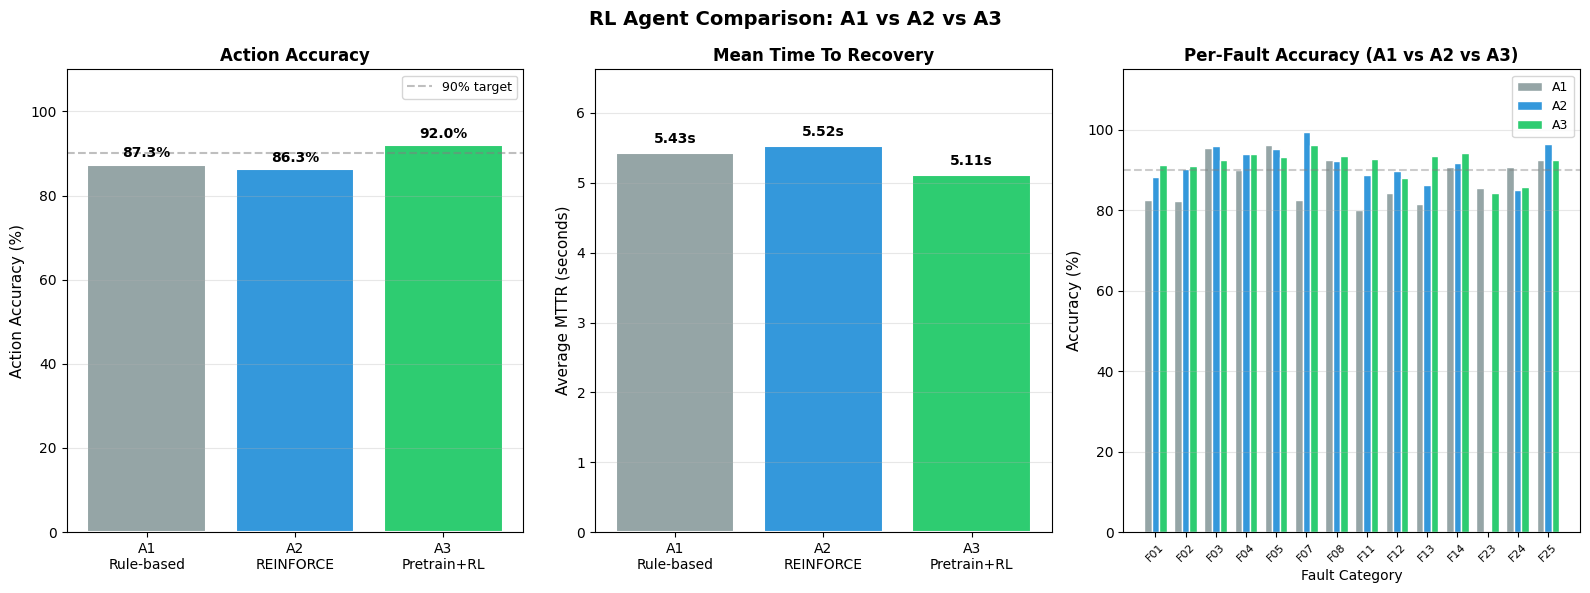


Chart saved to rl_comparison.png


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('RL Agent Comparison: A1 vs A2 vs A3', fontsize=14, fontweight='bold')
 
agents  = ['A1\nRule-based', 'A2\nREINFORCE', 'A3\nPretrain+RL']
colors  = [ '#95a5a6', '#3498db', '#2ecc71']
acc     = [a1_results['accuracy'],
           a2_results['accuracy'],     a3_results['accuracy']]
mttrs   = [a1_results['avg_mttr'],
           a2_results['avg_mttr'],     a3_results['avg_mttr']]
 
# Chart 1 — Accuracy
ax1 = axes[0]
bars = ax1.bar(agents, acc, color=colors, edgecolor='white', linewidth=1.5)
ax1.set_ylabel('Action Accuracy (%)', fontsize=11)
ax1.set_title('Action Accuracy', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 110)
ax1.axhline(y=90, color='gray', linestyle='--', alpha=0.5, label='90% target')
for bar, val in zip(bars, acc):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
             f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)
ax1.grid(axis='y', alpha=0.3)
ax1.legend(fontsize=9)
 
# Chart 2 — MTTR
ax2 = axes[1]
bars2 = ax2.bar(agents, mttrs, color=colors, edgecolor='white', linewidth=1.5)
ax2.set_ylabel('Average MTTR (seconds)', fontsize=11)
ax2.set_title('Mean Time To Recovery', fontsize=12, fontweight='bold')
ax2.set_ylim(0, max(mttrs) * 1.2)
for bar, val in zip(bars2, mttrs):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
             f'{val:.2f}s', ha='center', va='bottom', fontweight='bold', fontsize=10)
ax2.grid(axis='y', alpha=0.3)
 
# Chart 3 — Per-fault accuracy (A1 vs A2 vs A3)
ax3 = axes[2]
cats   = sorted(a3_results['per_fault'].keys())
x      = np.arange(len(cats))
width  = 0.25
 
bars_a1 = ax3.bar(x - width, [a1_results['per_fault'].get(c,0) for c in cats],
                   width, label='A1', color='#95a5a6', edgecolor='white')
bars_a2 = ax3.bar(x,         [a2_results['per_fault'].get(c,0) for c in cats],
                   width, label='A2', color='#3498db', edgecolor='white')
bars_a3 = ax3.bar(x + width, [a3_results['per_fault'].get(c,0) for c in cats],
                   width, label='A3', color='#2ecc71', edgecolor='white')
 
ax3.set_xlabel('Fault Category', fontsize=10)
ax3.set_ylabel('Accuracy (%)', fontsize=11)
ax3.set_title('Per-Fault Accuracy (A1 vs A2 vs A3)', fontsize=12, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(cats, rotation=45, fontsize=8)
ax3.set_ylim(0, 115)
ax3.axhline(y=90, color='gray', linestyle='--', alpha=0.4)
ax3.legend(fontsize=9)
ax3.grid(axis='y', alpha=0.3)
 
plt.tight_layout()
plt.savefig('rl_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved to rl_comparison.png")